In [ ]:
import pandas as pd

import os # To work with operating system functionalities
print(os.getcwd())


c:\Users\Noor Saba\Dropbox\PC\Downloads\Data Science with Python


In [13]:
import pandas as pd

# Correct file path
file_path = r"C:\Users\Noor Saba\Dropbox\PC\Downloads\Data Science with Python\customers.csv"

# Load the dataset
df = pd.read_csv(file_path)



In [14]:
print("First 5 rows of the dataset:") # Display first few rows
print(df.head())


First 5 rows of the dataset:
   CustomerID               Name   Age  Gender  Annual Income  Spending Score
0           1      Lorraine Hall  62.0  Female        68395.0            36.0
1           2         David Khan  65.0  Female        90155.0            92.0
2           3       Patrick Rose  18.0  Female        68214.0             NaN
3           4   Joel Wilson-Rees  21.0    Male        30469.0            37.0
4           5  Kirsty Owen-Jones  21.0  Female        73295.0            49.0


In [15]:
print("\nDataset info:") # Quick overview of the dataset
print(df.info())



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      105 non-null    int64  
 1   Name            105 non-null    object 
 2   Age             95 non-null     float64
 3   Gender          105 non-null    object 
 4   Annual Income   94 non-null     float64
 5   Spending Score  95 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 5.1+ KB
None


In [16]:
print("\nSummary statistics for numerical columns:") # Statistical summary
print(df.describe())


Summary statistics for numerical columns:
       CustomerID        Age  Annual Income  Spending Score
count  105.000000  95.000000      94.000000       95.000000
mean    51.142857  41.989474  101438.468085       50.705263
std     29.088535  15.539582   64131.556824       28.649338
min      1.000000  18.000000   30469.000000        1.000000
25%     26.000000  29.500000   64128.750000       25.500000
50%     51.000000  41.000000   93208.000000       49.000000
75%     76.000000  54.500000  118820.750000       75.000000
max    100.000000  69.000000  424842.000000       97.000000


In [17]:
duplicate_rows = df[df.duplicated()] # Identify duplicate rows

print(f"Number of duplicate rows: {duplicate_rows.shape[0]}") # Print number of duplicate rows
print(duplicate_rows)

df = df.drop_duplicates() # Remove duplicate rows


Number of duplicate rows: 5
     CustomerID                   Name   Age Gender  Annual Income  \
100          47         Lawrence Evans  50.0   Male        92885.0   
101          92           Liam Bradley  21.0   Male        30894.0   
102          26         Leanne Stanley  31.0  Other        87368.0   
103          99        Mr Damian Brady  53.0   Male       268803.0   
104          56  Julie Robinson-Morgan  68.0   Male            NaN   

     Spending Score  
100            59.0  
101             1.0  
102            23.0  
103            40.0  
104            68.0  


In [18]:
print(df.isnull().sum()) # Check for missing values

df['Age'].fillna(df['Age'].median(), inplace=True) # For numerical columns, fill missing with median
df['Annual Income'].fillna(df['Annual Income'].median(), inplace=True) 
df['Spending Score'].fillna(df['Spending Score'].median(), inplace=True)

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True) # For categorical columns, fill missing with mode


print(df.isnull().sum()) # Verify no missing values remain


CustomerID         0
Name               0
Age               10
Gender             0
Annual Income     10
Spending Score    10
dtype: int64
CustomerID        0
Name              0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64


C:\Users\Noor Saba\AppData\Local\Temp\ipykernel_27032\4171867722.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True) # For numerical columns, fill missing with median
C:\Users\Noor Saba\AppData\Local\Temp\ipykernel_27032\4171867722.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on wh

Age outliers:
Series([], Name: Age, dtype: float64)

Annual Income outliers:
14    336381.0
34    424842.0
80    319734.0
98    268803.0
Name: Annual Income, dtype: float64

Spending Score outliers:
Series([], Name: Spending Score, dtype: float64)



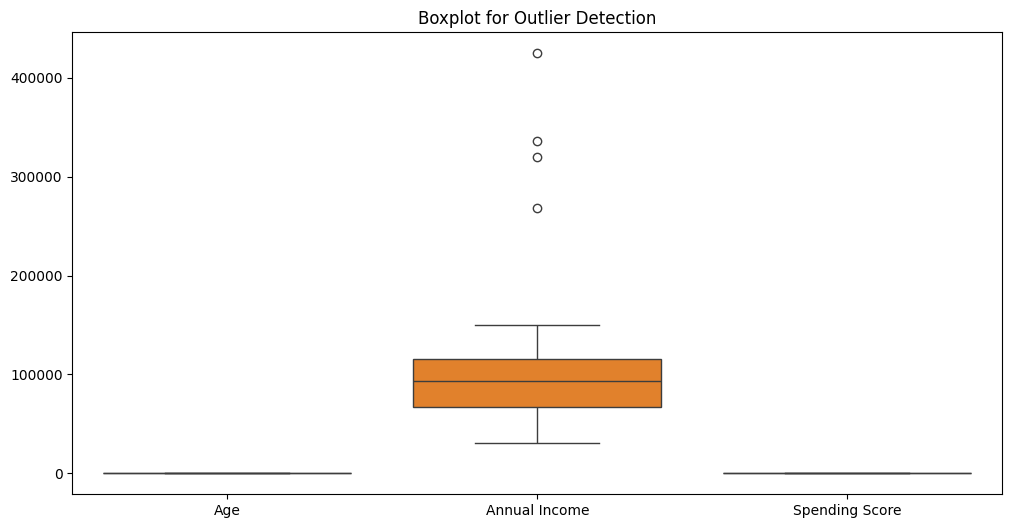

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def detect_outliers(column): # IQR method
    Q1 = column.quantile(0.25) # First quartile
    Q3 = column.quantile(0.75) # Third quartile
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR # Lower and upper bounds
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers


for col in ['Age', 'Annual Income', 'Spending Score']: # Check outliers for numerical columns
    outliers = detect_outliers(df[col])
    print(f"{col} outliers:\n{outliers}\n")


plt.figure(figsize=(12,6)) # Boxplot for visualizing outliers
sns.boxplot(data=df[['Age', 'Annual Income', 'Spending Score']])
plt.title('Boxplot for Outlier Detection')
plt.show()


In [20]:
# Winsorize numerical columns
for col in ['Age', 'Annual Income', 'Spending Score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
